# Imports

In [58]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor, Resize
from torchvision.io import read_image
from torchsummary import summary

import matplotlib.pyplot as plt
import numpy as np

import csv
import os

# Part 1

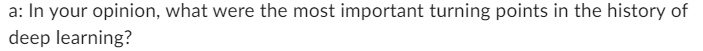

Throughout the history of deeplearning there have been immense amount of development but some historical turning points can sum up the important breakthroughs.

#### The Perceptron
In 1958 Frank Rosenblatt's perceptron was described modelling the earliest artificial neuron. A singular neuron could classify inputs into two categories by solving a linear regression problem. It was however limited by said linear behavior and could not solve non-linear problems leading to a deminishing interest at the time (First AI winter)

#### The Backpropagation algorithm 
In 1986 Geoffrey Hinton and others proposed the backpropagation algorithm for training multilayer neural networks by computing the gradient of the network weights. This discovery lead to a rising interest in the field once again.

#### Convolutional Neural Networks
In the 1989 one of the first CNN "LeNet5" was proposed. This gave the field of machine learning vision in the sense that LeNet5 was used to recognize written digits. This development put down the groundwork for AI computer vision. During the 90s computer power saw significant increase and thus more complex networks could be modelled and trained. Thist further sparked the interest in the field. 

#### Large data and GPU technology
During the 00s large scale labeled datasets combined with advancements in GPU technology lead to ever faster training and the possibility of implementing more complex networks. The advancements in the GPU technology have definitely helped to bring the possibilities of deep learning forward.

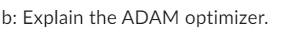

The ADAM (Adaptive Moment Estimation) optimizer builds on the workings of Stochastic Gradient Descent (SGD) optimization, where the gradient of the loss function based on parts of the training data. The optimizer is described by:
$$
\Theta_t = \Theta_{t-1} - \alpha\nabla J(\Theta_{t-1})
$$
Where $\Theta$ is the parameter(s) under optimization and $\alpha$ is a fixed learning rate. 

By adding a momentum into the equation the algorithm is enabled to have some memory in the sense, that it will not be thrown emmidiatly off cause by one gradient calculation that deviates from the rest. It will recall the previous direction from previous iterations and will be more robust. Introducing momentum in the SGD algorithm is described by:
$$
\Theta_t = \Theta_{t-1} - \alpha v_t
$$
Where:
$$
v_t = \gamma v_{t-1} + (1-\gamma)\nabla J(\Theta_{t-1})
$$
And $0\le\gamma<1$

With the addition of momentum we still have a fixed step size, $\alpha$, which we want to make adaptive such since small steps are likely to converge slow and large steps are more likely to overshoot and be unstable. So the problem of knowing what step size to choose can be helped by making it adaptive to the changes of the gradient. This is summarized in the RMSProp optimization scheme where the summation of the weighted gradients are computed as:
$$
sum_t = \beta sum_{t-1}+(1-\beta)(\nabla J(\Theta_{t-1}))^2
$$
Where $0\le\beta<1$ is a chosen parameter (often $~0.9$). The parameter is thereby updated as:
$$
\Theta_t = \Theta_{t-1}-\frac{\alpha}{\sqrt{\epsilon + sum_t}}\Theta_{t-1}
$$
And $\epsilon$ is a small number to prevent division by zero. 

Finally, the ADAM optimization scheme combines the RMSProp with the momentum described earlier to provide a smoothed weight update with an adaptive learning rate. The parameter update is described as:
$$
\Theta_t = \Theta_{t-1} - \frac{\alpha}{\sqrt{\epsilon + sum_t}}v_t
$$
Where $v_t$ is as described above. 
Hence the ADAM optimizer have four hyper parameters: 
- $\alpha$: Learning rate (often $~0.001$). 
- $\gamma$: The decay rate of the momentum  (often $~0.9$).
- $\beta$: The decay rate of the weighting of the previous gradients (often $~0.999$).
- $\epsilon$: A small value to prevent division by zero. 


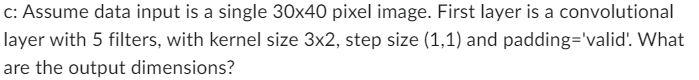

First of all padding='valid' means that the image will have no additional pixels padded around the edge prior to convolution. Thus by convolution the image will be smaller. 

When convolving with 5 filters the output will have 5 channels - one for each filter.

Upon convolution with one of the 5 filters the dimensions of the output will be 28x39 since the stride is (1,1). 

Therby the final output will be: 28x39x5


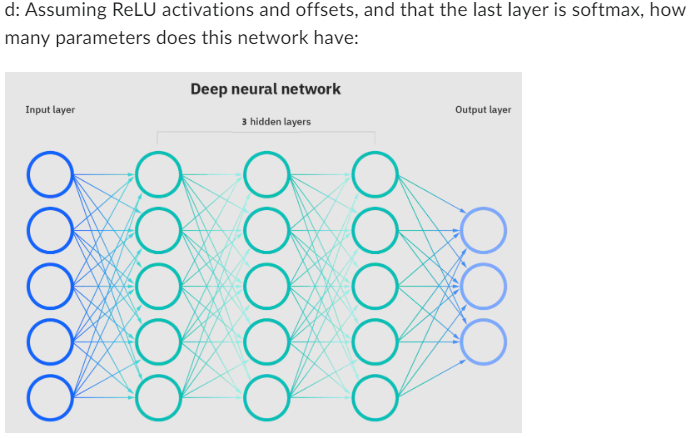

The number of parameters are the total number of weights and biases in the network. Since this the a fully connected neural network each neuron in the current layer is connected to each neuron in the subsequent layer - Each of these connection will have a weight assigned to them. In addition each neuron in the subsequent layer will have a bias associated with it. Hence for the connection between the input to the first hidden layer we will have:
$$
Weights = 5\times 5 = 25 \\
Biases = 5
$$
Summing to a total of 30 parameters in the first layer. 

The number of parameters from the connection between hidden layer 1 and 2 as well as hidden layer 2 and 3 will be the same.

The connections between the last hidden layer and the output layer will have:
$$
Weights = 5\times 3 = 15
Biases  = 3
$$

Hence the total number of paramters of the network is:
$$
Paramters = 3\times 30 + 18 = 108
$$

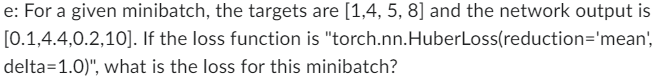

The HuberLoss function combines the advantages of Mean Squared Error and Mean Absolute Error losses making it robust to outliers. The HuberLoss will be like MSE for small errors and MAE for larger errors. It is defined as:
$$
L(y,\hat{y}) = \begin{cases}
0.5(y-\hat{y})^2, \quad\quad\quad for\ |y-\hat{y}|\le\delta\\
\delta(|y-\hat{y}|-0.5\delta)\quad for\ |y-\hat{y}|>\delta

\end{cases}
$$

In [59]:
def huberLossExample(y, yhat, delta=1):
    diff = abs(y-yhat)
    if diff <= delta:
        return 0.5*(diff)**2
    elif diff > delta:
        return delta*(diff-0.5*delta)

predictions = torch.tensor([0.1, 4.4, 0.2, 10])
targets = torch.tensor([1, 4, 5, 8])

data = zip(targets, predictions)
loss = 0
delta = 1
for y, yhat in data:
    loss += 1/len(predictions)*huberLossExample(y,yhat,delta)
print("Huber Loss: ", loss.numpy())

Huber Loss:  1.5712501


In [60]:
#Using Torch
huber_loss = torch.nn.HuberLoss(reduction='mean', delta=1.0)
loss = huber_loss(predictions, targets)
print(f"Huber Loss: {loss.item()}")

Huber Loss: 1.571250081062317


# Part 2: Writing a PyTorch Dataset

In [61]:
path = "C:/Users/bjark/OneDrive/Documents/Uni/Semester_09/Deep_Learning/Assignment_01"
file = path + '/insects.csv'
images = path + '/Insects/'

In [62]:
class InsectData(Dataset):
    def __init__(self, labels_file, img_folder, transform = None):
        self.transform = transform
        self.image_folder = img_folder
        self.labels_file = labels_file
        self.image_size = (520, 520)
        
        self.labels, self.filenames = self.__get_annotations() 
        self.class_map = self.__get_class_map()
        
    def __len__(self):
        return len(self.labels)

    def __get_annotations(self): #Return both labels and filenames of the csv file
        labels = []
        filesnames = []
        with open(self.labels_file, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                label = row["species"]
                filename = row["filename"]
                labels.append(label)
                filesnames.append(filename)
        return labels, filesnames
    
    def __get_class_map(self): # Mapping class species to integers
        types_of_species = set(self.labels)
        class_map = {}
        for i, t in enumerate(types_of_species):
            class_map.update({t: i})
        return class_map
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img_name = os.path.join(self.image_folder, self.filenames[idx])
        image = read_image(img_name)
        resize = Resize(self.image_size)
        image = resize(image)
        label = self.class_map[self.labels[idx]]
        label = torch.tensor([label])
        return image, label

<!-- # Part 3 -->

Testing the dataset with the provided dataset tester. 

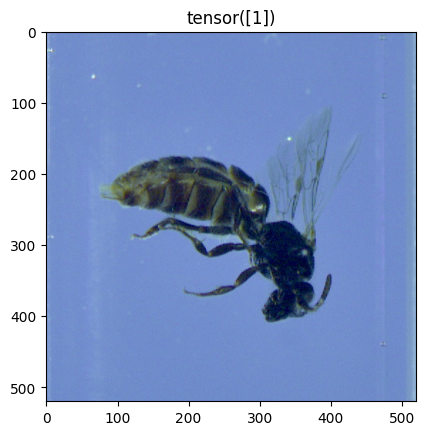

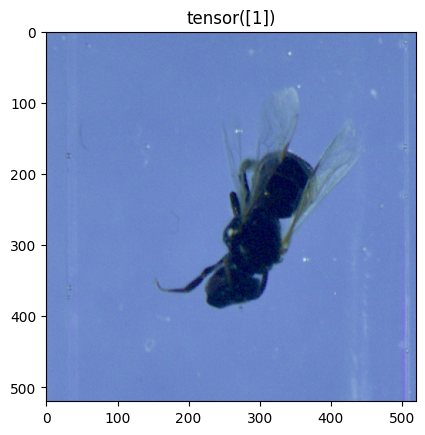

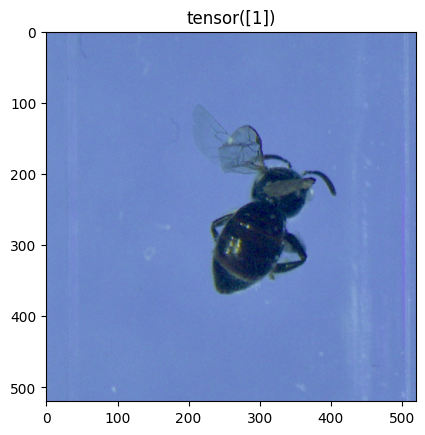

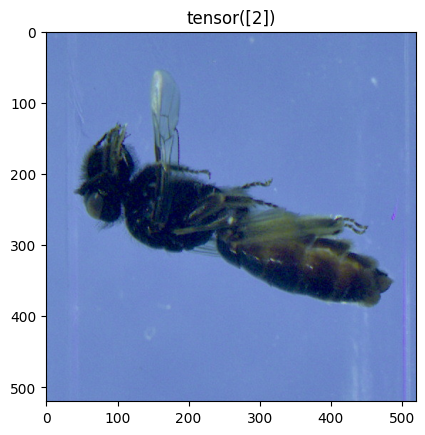

In [63]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
transform = transforms.Compose([transforms.ToTensor()])
batch_size = 2
# Set up the dataset.
dataset = InsectData(file, images, transform)
# Set up the dataset.
trainloader = torch.utils.data.DataLoader(dataset,
                                          batch_size=batch_size,
                                          shuffle=True)
# get some images
dataiter = iter(trainloader)
imgs, labs = next(dataiter)

for i in range(2): #Run through 5 batches
    imgs, labs = next(dataiter)
    for image, label in zip(imgs,labs): # Run through all samples in a batch
        plt.figure()
        plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
        plt.title(label)

# Part 3

In [64]:
path = "C:/Users/bjark/OneDrive/Documents/Uni/Semester_09/Deep_Learning/Assignment_01"
train_data = path + "/trainData.txt"
test_data = path + "/testData.txt"

A handler function is written to handle the data files. This function splits the data into labels, x_features, and y_features. 

In [65]:
def txtHandler(txtfile):
    labels = []
    xfeat = []
    yfeat = []
    with open(txtfile, newline='') as f:
        reader = csv.reader(f, delimiter=' ')
        for row in reader:
            labels.append(float(row[0]))
            xfeat.append(float(row[1]))
            yfeat.append(float(row[2]))
    return labels, xfeat, yfeat


In [66]:
train_targets, train_x, train_y = txtHandler(train_data)
test_targets, test_x, test_y = txtHandler(test_data)

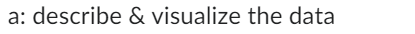

The data is plotted in a scatter plot and the classes are visualized using a corresponding color. As we can see we have 5 classes in this dataset corresponding to each of the arms in the galaxy-like order.

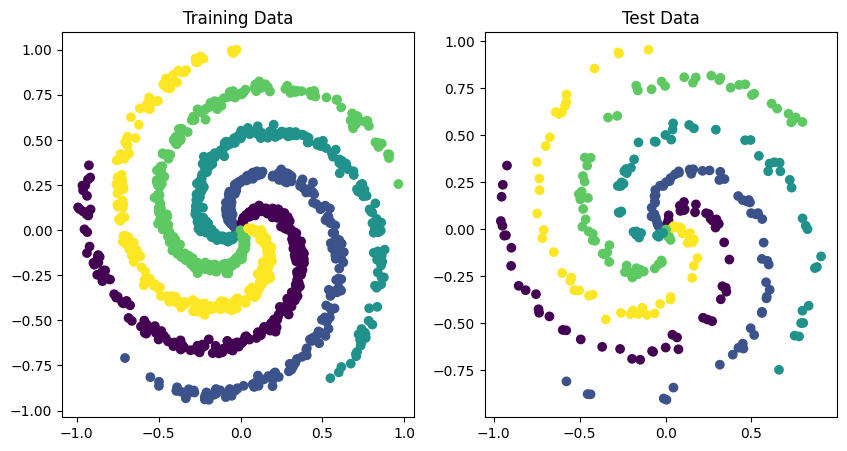

In [67]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].scatter(train_x, train_y, c = train_targets)
ax[0].set_title("Training Data")
ax[1].scatter(test_x, test_y, c = test_targets)
ax[1].set_title("Test Data")
plt.show()

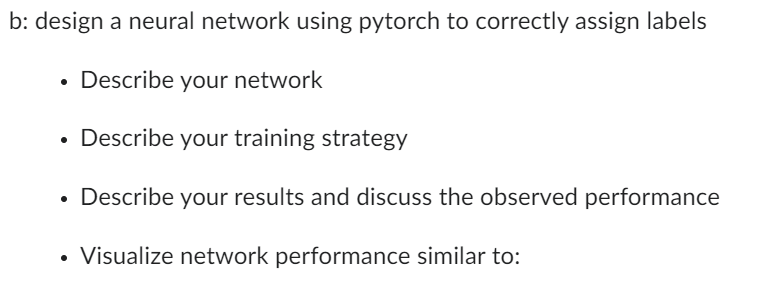

To allow for easy use of the PyTorch library the data is gathered in tensor datasets. 

In [68]:
trainDataset = TensorDataset(torch.tensor(train_x).float(), torch.tensor(train_y), torch.tensor(train_targets).long())
testDataset = TensorDataset(torch.tensor(test_x).float(), torch.tensor(test_y), torch.tensor(test_targets).long())

The dataloaders are configured allowing the network to be trained on minibatches of chosen size 32. 

In [69]:
batch_size = 32

train_dataloader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testDataset, batch_size=batch_size, shuffle=True)

The Neural Network model is then defined. I have made a fully connected MLP with 2 hidden layers. 

- The input layer have 2 input features since the feature space of the training data is two-dimensional.
- The first hidden layer 256 input features. Its activation function is ReLU. 
- The second hidden layer has 128 input features and ReLU activation function. 
- The output layer has 64 input features and 5 output features corresponding to the 5 classes. There is no activation function on the output as this will be taken care of by the CrossEntropyLoss function. The loss function will effectively implement a Softmax activation function of the model output. Therefore, Softmax is not defined at the output function. 


In [70]:
class my_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.inputLayer = nn.Linear(in_features=2, out_features=256, bias=True)
        self.layerOne = nn.Linear(in_features=256, out_features=128, bias=True)
        self.layerTwo = nn.Linear(in_features=128, out_features=64, bias=True)
        self.outputLayer = nn.Linear(in_features=64, out_features=5, bias=True)
        self.Relu = nn.ReLU()
        
    def forward(self, x):
        x = self.inputLayer(x)
        x = self.Relu(x)
        x = self.layerOne(x)
        x = self.Relu(x)
        x = self.layerTwo(x)
        x = self.Relu(x)
        x = self.outputLayer(x)
        return torch.squeeze(x)        

The model can be summarized as follows:

In [71]:
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu")

model = my_model().to(device)
summary(model, input_size=(1,2))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 256]             768
              ReLU-2               [-1, 1, 256]               0
            Linear-3               [-1, 1, 128]          32,896
              ReLU-4               [-1, 1, 128]               0
            Linear-5                [-1, 1, 64]           8,256
              ReLU-6                [-1, 1, 64]               0
            Linear-7                 [-1, 1, 5]             325
Total params: 42,245
Trainable params: 42,245
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.16
Estimated Total Size (MB): 0.17
----------------------------------------------------------------


The loss function of the training procedure is chosen to be CrossEntropyLoss. This is chosen due to the problem being a multi-label classification problem.
The optimizer is chosen to be Adam due to much better performance compared to SGD. 
The learning rate is set to 0.001

In [72]:
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

The training procedure will now begin. During training the test data is used to evaluate the performance of the model. When the test accuracy is sufficiently large, the training loop is dicontinued and the model performance can be evaluated. 

In [73]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss, correct = 0, 0

    for batch, (x, y, t) in enumerate(dataloader):
        X = torch.tensor([x.numpy(), y.numpy()])
        X = torch.transpose(X, 0, 1)
        X, t = X.to(device), t.to(device)
        
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, t)
        total_loss += loss.item()  # Accumulate loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Calculate accuracy
        correct += (pred.argmax(1) == t).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            
    avg_loss = total_loss / len(dataloader)  # Calculate average loss for the epoch
    avg_accuracy = correct / size

    train_losses.append(avg_loss)  # Store the average loss for the epoch
    train_accuracies.append(avg_accuracy) # Store the average accuracy for the epoch
    return avg_accuracy, avg_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for x, y, t in dataloader:
            X = torch.tensor(np.array([x.numpy(), y.numpy()]))
            X = torch.transpose(X, 0, 1)
            X, t = X.to(device), t.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, t).item()
            correct += (pred.argmax(1) == t).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    test_losses.append(test_loss)  # Store the test loss for the epoch
    test_accuracies.append(correct)
    return correct, test_loss

In [74]:
epochs = 100
for t in range(epochs):
    train_acc, train_loss = train(train_dataloader, model, loss_fn, optimizer)
    test_acc, test_loss = test(test_dataloader, model, loss_fn)
    print(f"Epoch {t+1}: Test Accuracy {round(test_acc,4)} // Test Loss {round(test_loss,4)}", end="\r")
    if test_acc > 0.99: #Stop training if test accuracy is sufficiently good
        epochs = t+1
        break
print(f"Done! Final test accuracy: {round(test_acc, 4)}, Final test loss: {round(test_loss,4)}")


Done! Final test accuracy: 0.9967, Final test loss: 0.0518


Plotting the training and testing accurcy and loss over Epochs to visualize the training procedure. 

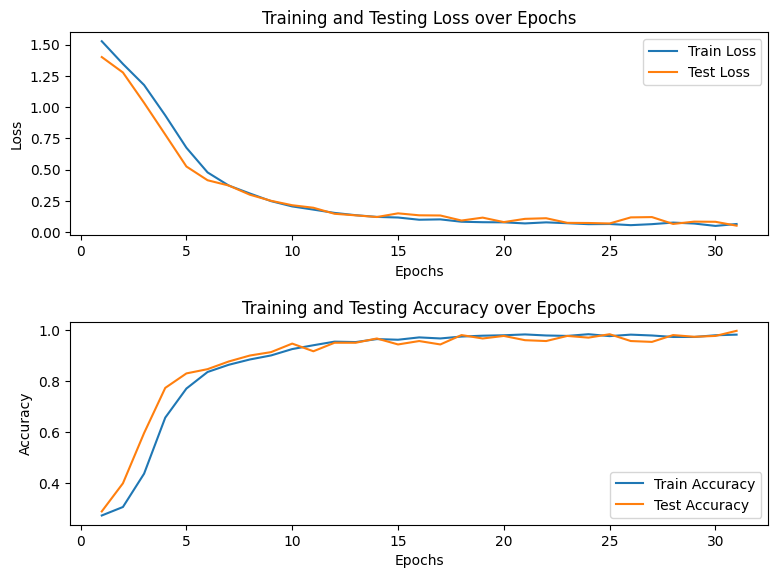

In [75]:
fix, ax = plt.subplots(2, 1, figsize = (8,6))
ax[0].plot(range(1, epochs+1), train_losses, label="Train Loss")
ax[0].plot(range(1, epochs+1), test_losses, label="Test Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training and Testing Loss over Epochs")
ax[0].legend()

ax[1].plot(range(1, epochs+1), train_accuracies, label="Train Accuracy")
ax[1].plot(range(1, epochs+1), test_accuracies, label="Test Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training and Testing Accuracy over Epochs")
ax[1].legend()
plt.tight_layout(pad=1.5)
plt.show()

Sampling the 2D space uniformly, feeding them through the trained model, and plotting them. Now decision boundaries can be visualized. 

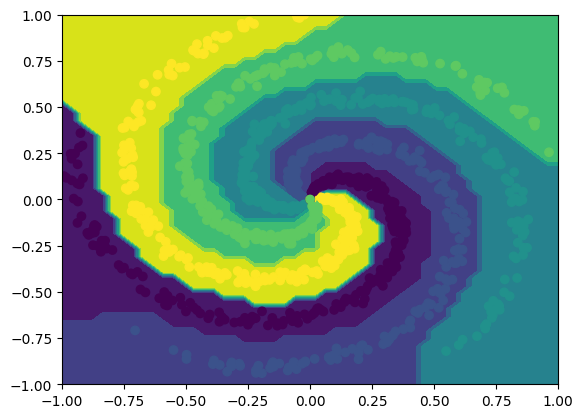

In [76]:
model.cpu()
x,y = np.meshgrid(np.linspace(-1,1,50),np.linspace(-1,1,50))
xy = np.concatenate((x.reshape(-1,1),y.reshape(-1,1)),axis=1)
z = model(torch.tensor(xy).float()).detach().numpy()
z = np.argmax(z,1).reshape(50,50)
plt.contourf(x,y,z)
plt.scatter(train_x, train_y, c=train_targets)
plt.show()